# Notebook 02 — Exploratory Balancing Analysis

## Objective

Explore the statistical and operational behaviour of
balancing spreads within the GB Balancing Mechanism.

The notebook investigates:
- spread distributions,
- wind relationships,
- stress regimes,
- intraday structure,
- and early evidence of balancing-market disequilibrium.

This notebook is exploratory in nature and is intended
to establish initial market-state intuition prior to
formal fair-value modelling.

## 1. Load Processed Modelling Dataset

This notebook loads the enriched modelling dataset
constructed in Notebook 01.

The dataset includes:
- system prices,
- balancing VWAP estimates,
- wind generation,
- regional demand,
- and engineered timestamps.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_parquet(
    "../data/processed/modelling_dataset_enriched.parquet"
)

print(df.shape)
print(df.columns)

(17524, 10)
Index(['date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key', 'wind_mw',
       'timestamp', 'system_price', 'bm_bid_price_vwap', 'basis_spread'],
      dtype='object')


## 2. Construct Exploratory Market-State Variables

Several derived variables are constructed to support
exploratory analysis:

| Variable | Description |
|---|---|
| relative_spread | Spread normalised by system price |
| stress | High-price stress regime indicator |
| hour | Intraday timing variable |
| month | Calendar-season indicator |

These variables are used throughout the notebook
to explore temporal and operational market structure.

In [29]:
df_valid = df.dropna(
    subset=['basis_spread']
).copy()

print(df_valid.shape)

# =========================================================
# FEATURE CONSTRUCTION
# =========================================================

df_valid['relative_spread'] = (
    df_valid['basis_spread'] /
    df_valid['system_price']
)

df_valid['hour'] = (
    pd.to_datetime(df_valid['timestamp']).dt.hour
)

df_valid['stress'] = (
    df_valid['system_price'] > 300
).astype(int)

df_valid['month'] = (
    pd.to_datetime(df_valid['timestamp']).dt.month
)

(120, 10)


## Important Coverage Note

The balancing VWAP construction currently produces
a relatively sparse dataset.

Although the full modelling dataset contains over
17,000 settlement periods, only a limited subset
contains valid balancing VWAP observations after:
- balancing-action filtering,
- accepted-volume construction,
- and VWAP aggregation.

As a result:
- this notebook should be interpreted as exploratory,
- not yet fully representative of all settlement periods,
- and primarily useful for identifying broad structural behaviour.

Later notebooks substantially expand and refine the
market-state dataset.

In [30]:
print("Rows in modelling dataset:", len(df))
print("Rows with BM VWAP:", df['bm_bid_price_vwap'].notna().sum())

print("\nMissing ratios:")
print(
    df[
        [
            'system_price',
            'bm_bid_price_vwap',
            'basis_spread'
        ]
    ].isna().mean()
)

Rows in modelling dataset: 17524
Rows with BM VWAP: 120

Missing ratios:
system_price         0.000399
bm_bid_price_vwap    0.993152
basis_spread         0.993152
dtype: float64


### Interpretation

The dataset currently contains a relatively small number
of valid balancing VWAP observations compared with the
full settlement-period universe.

This reflects:
- filtering of balancing actions,
- directional VWAP construction,
- and sparsity in accepted bid activity.

The result highlights one of the key engineering
challenges in balancing-market analysis:
constructing robust operational pricing proxies
from incomplete balancing-action data.

## 3. Distributional Analysis

This section explores:
- spread distributions,
- scale,
- skewness,
- and broad pricing behaviour.

The objective is to determine whether balancing spreads
appear:
- stable,
- symmetric,
- or regime-dependent.

In [31]:
print(
    df_valid[
        [
            'system_price',
            'bm_bid_price_vwap',
            'basis_spread',
            'relative_spread'
        ]
    ].describe()
)

       system_price  bm_bid_price_vwap  basis_spread  relative_spread
count    120.000000         120.000000    120.000000       120.000000
mean     292.988583         -45.065575    338.054158         1.059627
std      126.430444          76.191728    167.279437         0.607458
min       42.440000        -148.680000    -97.560000        -2.298775
25%      204.420000         -84.640000    274.597500         1.055478
50%      273.905000         -49.488333    317.050000         1.173578
75%      364.062500         -20.000000    462.185000         1.361417
max      665.760000         177.800000    685.760000         1.619030


Histogram interpretation

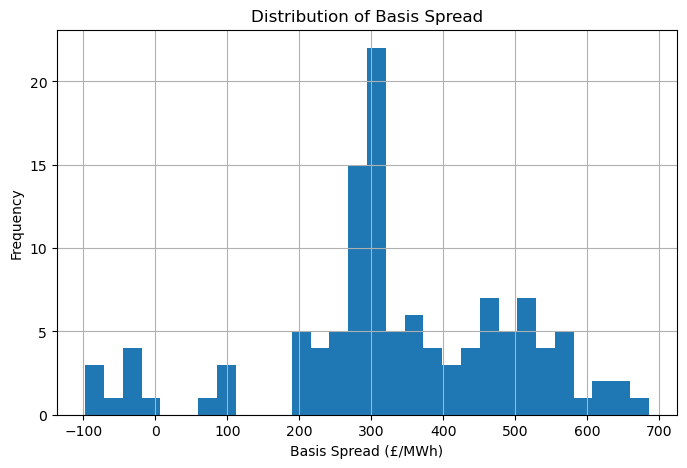

In [32]:
plt.figure(figsize=(8,5))

df_valid['basis_spread'].hist(bins=30)

plt.xlabel("Basis Spread (£/MWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Basis Spread")

plt.show()

### Initial Observation

Balancing spreads appear:
- highly dispersed,
- asymmetric,
- and heavy-tailed.

This suggests that balancing behaviour may be dominated
by stress regimes and operational scarcity events
rather than stable Gaussian dynamics.

In [ ]:
Wind scatter interpretation

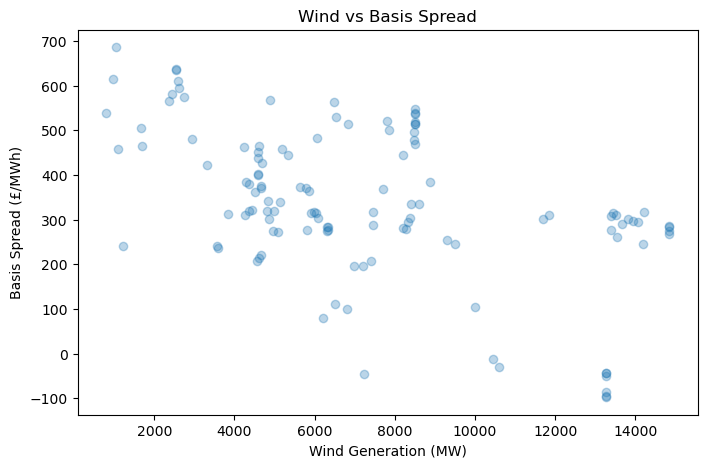

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_valid['wind_mw'],
    df_valid['basis_spread'],
    alpha=0.3
)

plt.xlabel("Wind Generation (MW)")
plt.ylabel("Basis Spread (£/MWh)")
plt.title("Wind vs Basis Spread")

plt.show()

### Initial Observation

Higher wind generation appears broadly associated
with lower balancing spreads.

This is consistent with the intuition that:
- high renewable output may reduce wholesale scarcity,
- compress balancing spreads,
- and lower operational stress.

## 4. Correlation Structure

This section investigates pairwise relationships between:
- wind generation,
- regional demand,
- system prices,
- balancing VWAP,
- and balancing spreads.

The objective is not causal inference,
but rather identification of broad structural relationships.

In [34]:
corr = df_valid[
    [
        'wind_mw',
        'sw_demand_mw',
        'system_price',
        'bm_bid_price_vwap',
        'basis_spread'
    ]
].corr()

print(corr)

                    wind_mw  sw_demand_mw  system_price  bm_bid_price_vwap  \
wind_mw            1.000000      0.488660     -0.615443           0.097870   
sw_demand_mw       0.488660      1.000000     -0.359687          -0.177838   
system_price      -0.615443     -0.359687      1.000000          -0.321427   
bm_bid_price_vwap  0.097870     -0.177838     -0.321427           1.000000   
basis_spread      -0.509732     -0.190852      0.902206          -0.698411   

                   basis_spread  
wind_mw               -0.509732  
sw_demand_mw          -0.190852  
system_price           0.902206  
bm_bid_price_vwap     -0.698411  
basis_spread           1.000000  


## 5. Wind-Regime Analysis

Wind generation is segmented into quartile-based regimes
to explore whether balancing spreads vary systematically
across renewable-output conditions.

This analysis provides early evidence for:
- renewable-driven spread compression,
- and regime-dependent balancing behaviour.

In [35]:
wind_bins = pd.qcut(df_valid['wind_mw'], 4)

wind_summary = (
    df_valid
    .groupby(wind_bins, observed=False)['basis_spread']
    .mean()
)

print(wind_summary)

wind_mw
(788.599, 4594.467]      447.688167
(4594.467, 6330.941]     337.925439
(6330.941, 8529.583]     373.224000
(8529.583, 14846.706]    193.379027
Name: basis_spread, dtype: float64


## 6. Stress-Regime Analysis

A simple stress indicator is constructed using:
- system prices above £300/MWh.

The objective is to determine whether balancing spreads
behave differently during operational stress conditions.

In [36]:
df_valid['stress'] = (
    df_valid['system_price'] > 300
).astype(int)

In [37]:
stress_summary = (
    df_valid
    .groupby('stress')['basis_spread']
    .describe()
)

print(stress_summary)

        count        mean         std     min        25%      50%       75%  \
stress                                                                        
0        70.0  234.453033  128.921110  -97.56  215.12550  279.715  309.4400   
1        50.0  483.095733   88.052086  334.28  406.31125  480.770  539.2525   

           max  
stress          
0       444.30  
1       685.76  


### Key Finding

Stress periods exhibit substantially larger balancing spreads.

This suggests that:
- balancing dynamics become materially different during
  high-price operational conditions,
- and balancing spreads may contain regime-dependent structure.

## 7. Intraday Structure

This section explores whether balancing spreads
vary systematically through the day.

Intraday structure may reflect:
- demand cycles,
- renewable intermittency,
- and operational balancing behaviour.

In [39]:
hourly = (
    df_valid
    .groupby('hour')['basis_spread']
    .mean()
)

print(hourly)

hour
0     451.320000
1     443.640000
4     273.115000
5     300.210000
6     479.340000
7     398.226000
8     359.748974
9     325.771250
10    379.787407
11    362.123143
12    322.477143
13    396.310722
15    276.710000
16    290.657500
17    215.243217
18    322.395385
19    311.463710
20    319.628333
21    370.047917
22    303.460000
Name: basis_spread, dtype: float64


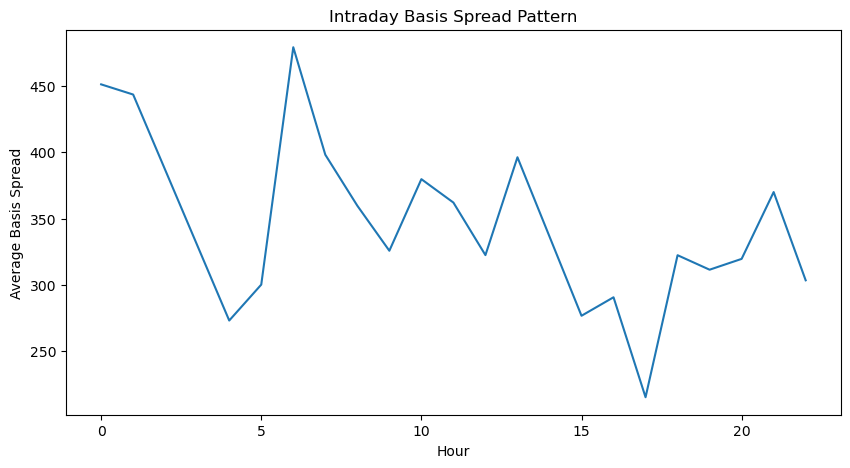

In [40]:
plt.figure(figsize=(10,5))

hourly.plot()

plt.xlabel("Hour")
plt.ylabel("Average Basis Spread")
plt.title("Intraday Basis Spread Pattern")

plt.show()

## 8. Extreme Event Inspection

The largest balancing-spread events are examined directly
to identify:
- operational characteristics,
- wind conditions,
- and system-price behaviour.

This provides intuition regarding the physical conditions
associated with extreme balancing stress.

In [41]:
extreme = (
    df_valid
    .sort_values('basis_spread', ascending=False)
    .head(10)
)

print(
    extreme[
        [
            'timestamp',
            'wind_mw',
            'sw_demand_mw',
            'system_price',
            'bm_bid_price_vwap',
            'basis_spread'
        ]
    ]
)

                timestamp      wind_mw  sw_demand_mw  system_price  \
11392 2022-08-26 09:00:00  1050.000000        1256.0        665.76   
11352 2022-08-25 13:00:00  2553.666667        1380.0        617.79   
11353 2022-08-25 13:30:00  2534.500000        1347.3        614.87   
11397 2022-08-26 11:30:00   974.166667        1158.0        594.82   
11350 2022-08-25 12:00:00  2592.000000        1418.2        590.38   
11349 2022-08-25 11:30:00  2611.166667        1417.2        574.00   
11273 2022-08-23 21:30:00  2441.500000        1337.7        558.63   
11250 2022-08-23 10:00:00  2745.066667        1377.1        547.07   
12323 2022-09-14 18:30:00  4895.833333        1518.0        448.41   
11362 2022-08-25 18:00:00  2362.000000        1449.5        544.67   

       bm_bid_price_vwap  basis_spread  
11392             -20.00        685.76  
11352             -20.00        637.79  
11353             -20.00        634.87  
11397             -20.00        614.82  
11350             -20.00

## 8. Extreme Event Inspection

The largest balancing-spread events are examined directly
to identify:
- operational characteristics,
- wind conditions,
- and system-price behaviour.

This provides intuition regarding the physical conditions
associated with extreme balancing stress.

In [42]:
df_normal = df_valid[df_valid['system_price'] < 300]

print(
    df_normal[
        ['wind_mw', 'basis_spread']
    ].corr()
)

               wind_mw  basis_spread
wind_mw       1.000000     -0.273151
basis_spread -0.273151      1.000000


## 9. Initial Exploratory Regression

A simple OLS regression is estimated using:
- wind generation,
- regional demand,
- and stress-state indicators.

This regression is exploratory only and should not be
interpreted as a causal or predictive model.

The objective is simply to test whether broad operational
state variables exhibit statistically detectable relationships
with balancing spreads.

In [43]:
X = df_valid[
    [
        'wind_mw',
        'sw_demand_mw',
        'stress'
    ]
]

X = sm.add_constant(X)

y = df_valid['basis_spread']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           basis_spread   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     56.01
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.86e-22
Time:                        13:41:43   Log-Likelihood:                -730.40
No. Observations:                 120   AIC:                             1469.
Df Residuals:                     116   BIC:                             1480.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          220.7352     57.174      3.861   

The regression results indicate that balancing spreads are primarily regime-driven. High-price stress periods are associated with substantially larger divergence between wholesale system prices and balancing mechanism bid prices.

Wind generation exhibits a statistically significant negative relationship with spread magnitude, although its effect is materially smaller than the stress regime effect.

The results suggest that balancing mechanism prices and wholesale market prices respond to different physical and economic signals during periods of system stress.

In [44]:
print(df.shape)
print(df_valid.shape)
print(df.isna().mean())

(17524, 10)
(120, 14)
date                 0.000000
sp                   0.000000
gspGroup             0.000000
sw_demand_mw         0.000000
sp_key               0.000000
wind_mw              0.000000
timestamp            0.000000
system_price         0.000399
bm_bid_price_vwap    0.993152
basis_spread         0.993152
dtype: float64


In [45]:
print(df_valid['timestamp'].min())
print(df_valid['timestamp'].max())

2022-01-01 12:30:00
2022-12-31 12:30:00


In [46]:
df_valid['month'] = df_valid['timestamp'].dt.month

print(df_valid['month'].value_counts().sort_index())

month
1     31
2     14
5      5
6      3
8     16
9     33
12    18
Name: count, dtype: int64


### Regression Interpretation

The regression suggests that balancing spreads are strongly
associated with operational stress conditions.

The stress-regime indicator exhibits substantially larger
explanatory power than wind generation alone, suggesting
that balancing spreads may be more closely linked to
system-state stress than to any single fundamental driver.

However:
- the sample remains sparse,
- the regression is exploratory,
- and significant omitted-variable risk remains.

These limitations motivate the more sophisticated
market-state and fair-value frameworks developed
in later notebooks.

# Notebook Summary

This notebook provided an initial exploratory investigation
into balancing-market behaviour.

Key observations included:
- strong spread dispersion,
- volatility clustering,
- regime-dependent behaviour,
- and evidence that operational stress materially affects
  balancing spreads.

The notebook also identified several important limitations:
- sparse balancing VWAP coverage,
- incomplete operational-state representation,
- and the need for more robust market-state engineering.

These findings motivated the richer feature engineering
and adaptive-equilibrium analysis developed in later notebooks.